>
> # MaaSSim tutorial

 ### quickstart

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys # add MaaSSim to path (not needed if MaaSSim is already in path)
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import MaaSSim

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


prepare

In [3]:
from MaaSSim.utils import get_config, load_G, prep_supply_and_demand, generate_demand, generate_demandX, generate_vehicles, initialize_df  # simulator
from MaaSSim.data_structures import structures as inData
from MaaSSim.simulators import simulate
from MaaSSim.visualizations import plot_veh
import logging

In [4]:
import pandas as pd

In [5]:
import ExMAS

In [6]:
params = get_config('../../data/config/delft.json')  # load configuration

In [7]:
params.times.pickup_patience = 3600 # 1 hour of simulation
params.simTime = 4 # 1 hour of simulation
params.nP = 500 # reuqests (and passengers)
params.nV = 100 # vehicles

In [8]:
params = MaaSSim.utils.get_config('glance.json')
params.city = "Delft, Netherlands"
params.paths.G = "../../data/graphs/Delft.graphml"
params.paths.skim = "../../data/graphs/Delft.csv"

params.vehicle_fixed_positions = True
params.times.patience = 600 #second
params.dist_threshold = 20000 #meter
params.dist_threshold_min = 3000 #meter

params.d2d.probabilistic = True
params.d2d.heterogeneous = False
params.proportional_std = 0.1 # proportional standard deviation [0.1, 0.2, 0.3] for both VoT & RW distributions
params.d2d.ini_att = 0.01
params.d2d.B_income = 1

params.d2d.B_inveh_time = 1
params.d2d.B_exp_time = 2 #1.5 in Oded's paper
params.PT_fare = 1 ## euro
params.PT_avg_speed = 6

params.nPM = 1 # number of platforms. platform id starts from 1
params.platforms.base_fare = 1.4 #euro 
params.platforms.fare = float(1.2)# float(1.20) #euro/km #http://taxihowmuch.com/
params.platforms.min_fare = float(4) # euro #http://taxihowmuch.com/
params.d2d.fuel_cost = 0.25 #euro/km #https://help.ubercarshare.com/hc/en-gb/articles/360022882131-Choosing-your-car-s-distance-rate  
params.platforms.comm_rate = float(0.20) # float(0.20) for baseline
params.platforms.discount = float(0.0) 
params.platforms.daily_marketing = False
params.platforms.incentive = float(0.0)

params.d2d.learning_d = 1 
params.d2d.B_Experience = 0.70
params.d2d.B_WOM = 0.20
params.d2d.B_Marketing = 0.10
params.d2d.diffusion_speed = 10/100 
params.d2d.m = 5
params.d2d.Eini_att = 0.01
params.d2d.adj_s = 2
params.VoT = 10.63 # value of time per hour
params.seed = 1
params.f_stop_crit = False
params.assert_me = False
# params.paths.requests = 'Amsterdam_requests.csv'

params.nP = 500
params.nV = 100
params.nD = 1 #7.5 years (July2012-Dec2019) * 12 months * 4 weeks = 360 weeks (days of simulation)
params.simTime = 4 
params.d2d.res_wage = params.simTime*11.16

In [9]:
params.t0 = pd.Timestamp.now()
params.shareability.avg_speed = params.speeds.ride
params.shareability.shared_discount = 0.3
params.shareability.delay_value = 1
params.shareability.WtS = 1.3
params.shareability.price = 1.5 #eur/km
params.shareability.VoT = 0.0035 #eur/s
params.shareability.matching_obj = 'u_pax' #minimize VHT for vehicles
params.shareability.pax_delay = 0
params.shareability.horizon = 600
params.shareability.max_degree = 4
params.shareability.nP = params.nP
params.shareability.share = 1
params.shareability.without_matching = True

In [10]:
inData = load_G(inData, params)  # load network graph 

In [11]:
inData = generate_demandX(inData, params, avg_speed = False)
# inData.vehicles = generate_vehicles(inData,params, params.nV)
# inData.vehicles.platform = inData.vehicles.apply(lambda x: 0, axis = 1)
# inData.passengers.platforms = inData.passengers.apply(lambda x: [0], axis = 1)
inData.requests['platform'] = inData.requests.apply(lambda row: inData.passengers.loc[row.name].platform, axis = 1) 
# inData.platforms = initialize_df(inData.platforms)
# inData.platforms.loc[0]=[1,'Uber',30] 
params.shareability.share = 1
params.shareability.without_matching = True

In [12]:
inData = ExMAS.main(inData, params.shareability, plot=False) # create shareability graph (ExMAS) 

07-03-25 14:28:41-INFO-Initializing pairwise trip shareability between 500 and 500 trips.
07-03-25 14:28:41-INFO-creating combinations
07-03-25 14:28:42-INFO-249500	 nR*(nR-1)
07-03-25 14:28:46-CRITICAL-LIFO pairs assertion failed
07-03-25 14:28:46-WARNING-Empty DataFrame
Columns: [origin_i, destination_i, ttrav_i, treq_i, delta_i, dist_i, VoT_i, origin_j, destination_j, ttrav_j, treq_j, delta_j, dist_j, VoT_j, i, j, t_oo, delay, delay_i, delay_j, t_od, t_dd, ttrav, kind, indexes, indexes_orig, indexes_dest, u_i, u_j, t_i, t_j, delta_ij, delta_ji, delta, u_pax]
Index: []

[0 rows x 35 columns]
07-03-25 14:28:46-WARNING-Empty DataFrame
Columns: [origin_i, destination_i, ttrav_i, treq_i, delta_i, dist_i, VoT_i, origin_j, destination_j, ttrav_j, treq_j, delta_j, dist_j, VoT_j, i, j, t_oo, delay, delay_i, delay_j, t_od, t_dd, ttrav, kind, indexes, indexes_orig, indexes_dest, u_i, u_j, t_i, t_j, delta_ij, delta_ji, delta, u_pax]
Index: []

[0 rows x 35 columns]
07-03-25 14:28:46-WARNING-Emp

In [17]:
import networkx as nx
import osmnx as ox

In [19]:
distance = nx.shortest_path_length(inData.G, source=44816479, target=44821573, weight="length")
distance

4374.032

In [15]:
inData.requests

,pax_id,origin,destination,treq,tdep,ttrav,tarr,tdrop,shareable,schedule_id,dist,platform,ride_id,position,sim_schedule
pax,,,,,,,,,,,,,,,
0,0,1515821435,2162745213,2025-03-07 12:29:09,NaN,0 days 00:09:02,2025-03-07 12:38:11,NaN,True,NaN,5429,1,0,0,node time req_id od 0 ...
1,1,44867153,1402734615,2025-03-07 12:29:24,NaN,0 days 00:07:21,2025-03-07 12:36:45,NaN,True,NaN,4414,1,1,0,node time req_id od 0 ...
2,2,5327428579,1404929838,2025-03-07 12:29:28,NaN,0 days 00:07:01,2025-03-07 12:36:29,NaN,True,NaN,4214,1,2,0,node time req_id od 0 ...
3,3,44836384,260125197,2025-03-07 12:29:52,NaN,0 days 00:07:24,2025-03-07 12:37:16,NaN,True,NaN,4441,1,3,0,node time req_id od 0 N...
4,4,2381851921,1552650958,2025-03-07 12:30:15,NaN,0 days 00:05:34,2025-03-07 12:35:49,NaN,True,NaN,3344,1,4,0,node time req_id od 0 ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,2560427063,2341955079,2025-03-07 16:25:30,NaN,0 days 00:06:11,2025-03-07 16:31:41,NaN,True,NaN,3717,1,495,0,node time req_id od 0 ...
496,496,1402734794,1436427147,2025-03-07 16:26:44,NaN,0 days 00:05:07,2025-03-07 16:31:51,NaN,True,NaN,3078,1,496,0,node time req_id od 0 ...
497,497,44846114,1608998330,2025-03-07 16:28:05,NaN,0 days 00:06:35,2025-03-07 16:34:40,NaN,True,NaN,3951,1,497,0,node time req_id od 0 ...


simulate

In [13]:
sim = simulate(params = params, inData = inData, logger_level = logging.WARNING) # simulate

07-03-25 14:29:55-INFO-Matching 500 trips to 533 rides in order to minimize u_pax
07-03-25 14:29:56-INFO-Problem solution: Optimal. 
Total costs for single trips:          3,060 
reduced by matching to:                3,001
07-03-25 14:29:59-WARNING-Setting up 4h simulation at 2025-03-07 12:29:09 for 100 vehicles and 500 passengers in Delft, Netherlands
Day =  0
07-03-25 14:30:38-WARNING-simulation time 35.8 s
nP =  500    nV =  100


<AxesSubplot:>

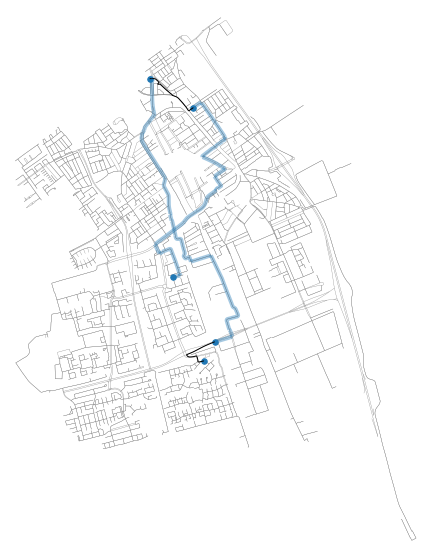

In [14]:
df = sim.runs[0].rides

for i in range(params.nV):
    paxes = df[df.veh==i].paxes
    if paxes.apply(lambda x: len(x)).max()>1:
        break
plot_veh(inData.G, df[df.veh ==19], lw = 1)

In [17]:
params.shareability.share = 0
sim2 = simulate(params = params, inData = inData, logger_level = logging.WARNING) # simulate

07-03-25 10:44:59-WARNING-Setting up 4h simulation at 2025-03-07 08:44:20 for 100 vehicles and 500 passengers in Delft, Netherlands
Day =  0
07-03-25 10:45:14-WARNING-simulation time 13.5 s
nP =  500    nV =  100


<AxesSubplot:>

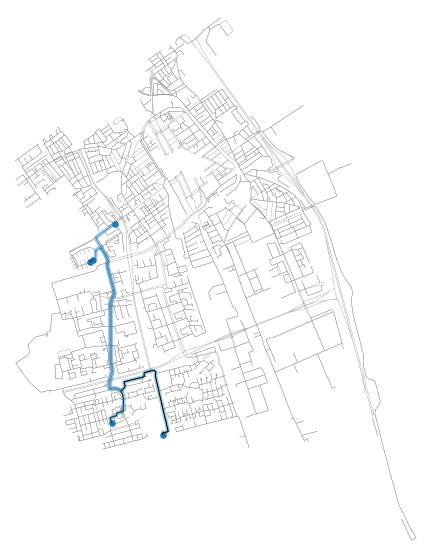

In [18]:
df = sim2.runs[0].rides

for i in range(params.nV):
    paxes = df[df.veh==i].paxes
    if paxes.apply(lambda x: len(x)).max()==1:
        break
plot_veh(inData.G, df[df.veh ==8], lw = 1)

-----